# 04a — Route Geometry: Lengths, Stop Sequences & Cross-LA Analysis

**Purpose:** Extract and analyse route geometry from BODS GTFS shapes.txt (3.2 GB uncompressed).
Produces route-level features needed for policy analysis and ML clustering (Layer 4).

**Inputs:**
- `data/raw/bods/bods_gtfs_all.zip` → shapes.txt (3.2 GB), routes.txt, trips.txt, stops.txt
- `data/raw/boundaries/lsoa_2021_england_buc.geojson` → LSOA boundaries with LA names

**Outputs:**
- `data/audit/route_geometries.parquet` — one row per route: length_km, stop_count, cross_la, route_type, operator, region
- `data/audit/route_stop_sequences.parquet` — ordered stop sequences per route

**Key finding:** shape_dist_traveled is 100% null in this feed — route lengths computed via Haversine.
48.5% of trips lack a shape_id — these routes are treated as geometry-missing and flagged separately.

**Ground truth:** 13,099 unique routes (GT-002), 1,752,443 trips (GT-003)

In [1]:
import zipfile
import io
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from loguru import logger

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

RAW = Path('../data/raw')
AUDIT = Path('../data/audit')
BODS_ZIP = RAW / 'bods' / 'bods_gtfs_all.zip'
LSOA_GEOJSON = RAW / 'boundaries' / 'lsoa_2021_england_buc.geojson'

# Locked ground truth
GT_UNIQUE_ROUTES = 13_099
GT_TOTAL_TRIPS = 1_752_443

logger.info('04a_route_geometry starting')

2026-03-14 00:03:08.472 | INFO     | __main__:<module>:26 - 04a_route_geometry starting


## 1. Load Core GTFS Tables

In [2]:
with zipfile.ZipFile(BODS_ZIP) as z:
    with z.open('routes.txt') as f:
        routes = pd.read_csv(f)
    with z.open('trips.txt') as f:
        trips = pd.read_csv(f)
    with z.open('stops.txt') as f:
        stops = pd.read_csv(f)
    with z.open('agency.txt') as f:
        agency = pd.read_csv(f)

logger.info(f'routes: {len(routes):,} rows')
logger.info(f'trips: {len(trips):,} rows')
logger.info(f'stops: {len(stops):,} rows')
logger.info(f'agency: {len(agency):,} rows')

print(f'Routes: {len(routes):,}')
print(f'Trips: {len(trips):,}')
print(f'Stops (GTFS feed): {len(stops):,}')
print(f'Agencies: {len(agency):,}')

2026-03-14 00:03:11.109 | INFO     | __main__:<module>:11 - routes: 13,640 rows


2026-03-14 00:03:11.110 | INFO     | __main__:<module>:12 - trips: 1,752,443 rows


2026-03-14 00:03:11.110 | INFO     | __main__:<module>:13 - stops: 310,598 rows


2026-03-14 00:03:11.110 | INFO     | __main__:<module>:14 - agency: 651 rows


Routes: 13,640
Trips: 1,752,443
Stops (GTFS feed): 310,598
Agencies: 651


In [3]:
# Route IDs in GTFS vs locked ground truth
# Note: GTFS routes.txt has 13,640 rows — the 13,099 figure is post-deduplication
# (same route in multiple regional feeds counted once)
# Here we work with GTFS route_ids as-is; dedup logic mirrors 02b
gtfs_route_count = len(routes)
print(f'GTFS route_ids (pre-dedup): {gtfs_route_count:,}')
print(f'Locked ground truth (post-dedup): {GT_UNIQUE_ROUTES:,}')

# Trips with vs without shape_id
trips_with_shape = trips['shape_id'].notna().sum()
trips_pct = trips_with_shape / len(trips) * 100
unique_shape_ids = trips['shape_id'].nunique()
print(f'\nTrips with shape_id: {trips_with_shape:,} ({trips_pct:.1f}%)')
print(f'Trips without shape_id: {trips["shape_id"].isna().sum():,} ({100 - trips_pct:.1f}%)')
print(f'Unique shape_ids: {unique_shape_ids:,}')

# Routes with at least one trip that has a shape_id
routes_with_shape = trips[trips['shape_id'].notna()]['route_id'].nunique()
routes_without_shape = trips[trips['shape_id'].isna()]['route_id'].nunique()
print(f'\nRoutes with at least one shaped trip: {routes_with_shape:,} ({routes_with_shape / gtfs_route_count * 100:.1f}%)')
print(f'Routes with zero shaped trips: {routes_without_shape:,} ({routes_without_shape / gtfs_route_count * 100:.1f}%)')

GTFS route_ids (pre-dedup): 13,640
Locked ground truth (post-dedup): 13,099

Trips with shape_id: 849,620 (48.5%)
Trips without shape_id: 902,823 (51.5%)
Unique shape_ids: 50,092

Routes with at least one shaped trip: 7,241 (53.1%)
Routes with zero shaped trips: 7,152 (52.4%)


## 2. Extract shapes.txt (Chunked — 3.2 GB)

In [4]:
def haversine_vectorised(lat1: np.ndarray, lon1: np.ndarray,
                          lat2: np.ndarray, lon2: np.ndarray) -> np.ndarray:
    """Compute Haversine distance in km between consecutive coordinate pairs.
    
    Args:
        lat1, lon1: Starting coordinates (degrees).
        lat2, lon2: Ending coordinates (degrees).
    
    Returns:
        Array of distances in kilometres.
    """
    R = 6371.0  # Earth radius km
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = (np.sin(dlat / 2) ** 2
         + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2) ** 2)
    return R * 2 * np.arcsin(np.sqrt(a))

In [5]:
# Read shapes.txt in chunks and accumulate per-shape length + bounding box
# shapes.txt: shape_id, shape_pt_lat, shape_pt_lon, shape_pt_sequence, shape_dist_traveled
# shape_dist_traveled is 100% null in this feed — length computed from coordinates

CHUNK_SIZE = 500_000
shape_accum: dict[str, dict] = {}  # shape_id → {length_km, n_points, min_lat, max_lat, min_lon, max_lon, last_lat, last_lon, last_seq}

logger.info('Reading shapes.txt in chunks ...')

with zipfile.ZipFile(BODS_ZIP) as z:
    with z.open('shapes.txt') as raw_f:
        reader = pd.read_csv(
            raw_f,
            usecols=['shape_id', 'shape_pt_lat', 'shape_pt_lon', 'shape_pt_sequence'],
            dtype={'shape_id': str, 'shape_pt_lat': float, 'shape_pt_lon': float, 'shape_pt_sequence': int},
            chunksize=CHUNK_SIZE,
        )
        for chunk_idx, chunk in enumerate(reader):
            # Sort within chunk by shape_id + sequence (chunks may interleave)
            chunk = chunk.sort_values(['shape_id', 'shape_pt_sequence'])

            for shape_id, grp in chunk.groupby('shape_id', sort=False):
                lats = grp['shape_pt_lat'].values
                lons = grp['shape_pt_lon'].values
                seqs = grp['shape_pt_sequence'].values

                if shape_id not in shape_accum:
                    shape_accum[shape_id] = {
                        'length_km': 0.0,
                        'n_points': 0,
                        'min_lat': lats.min(), 'max_lat': lats.max(),
                        'min_lon': lons.min(), 'max_lon': lons.max(),
                        'last_lat': None, 'last_lon': None, 'last_seq': -1,
                    }
                acc = shape_accum[shape_id]

                # Update bounding box
                acc['min_lat'] = min(acc['min_lat'], lats.min())
                acc['max_lat'] = max(acc['max_lat'], lats.max())
                acc['min_lon'] = min(acc['min_lon'], lons.min())
                acc['max_lon'] = max(acc['max_lon'], lons.max())
                acc['n_points'] += len(lats)

                # If this shape's first point in this chunk follows the last point
                # from a previous chunk, add cross-chunk segment
                if acc['last_lat'] is not None and seqs[0] > acc['last_seq']:
                    seg = haversine_vectorised(
                        np.array([acc['last_lat']]), np.array([acc['last_lon']]),
                        np.array([lats[0]]), np.array([lons[0]])
                    )
                    acc['length_km'] += float(seg[0])

                # Intra-chunk segment lengths
                if len(lats) > 1:
                    seg_km = haversine_vectorised(lats[:-1], lons[:-1], lats[1:], lons[1:])
                    acc['length_km'] += float(seg_km.sum())

                acc['last_lat'] = lats[-1]
                acc['last_lon'] = lons[-1]
                acc['last_seq'] = seqs[-1]

            if (chunk_idx + 1) % 10 == 0:
                logger.info(f'  chunk {chunk_idx + 1}: {len(shape_accum):,} unique shapes accumulated')

logger.info(f'shapes.txt read complete: {len(shape_accum):,} unique shape_ids')
print(f'Total unique shape_ids extracted: {len(shape_accum):,}')

2026-03-14 00:03:11.262 | INFO     | __main__:<module>:8 - Reading shapes.txt in chunks ...


2026-03-14 00:03:13.822 | INFO     | __main__:<module>:63 -   chunk 10: 4,847 unique shapes accumulated


2026-03-14 00:03:16.381 | INFO     | __main__:<module>:63 -   chunk 20: 9,751 unique shapes accumulated


2026-03-14 00:03:18.839 | INFO     | __main__:<module>:63 -   chunk 30: 14,549 unique shapes accumulated


2026-03-14 00:03:21.303 | INFO     | __main__:<module>:63 -   chunk 40: 19,432 unique shapes accumulated


...

2026-03-14 00:03:31.280 | INFO     | __main__:<module>:63 -   chunk 80: 38,506 unique shapes accumulated


2026-03-14 00:03:33.776 | INFO     | __main__:<module>:63 -   chunk 90: 43,371 unique shapes accumulated


2026-03-14 00:03:36.290 | INFO     | __main__:<module>:63 -   chunk 100: 48,250 unique shapes accumulated


2026-03-14 00:03:37.239 | INFO     | __main__:<module>:65 - shapes.txt read complete: 50,092 unique shape_ids


Total unique shape_ids extracted: 50,092


In [6]:
# Build shapes DataFrame
shapes_df = pd.DataFrame.from_dict(shape_accum, orient='index')
shapes_df.index.name = 'shape_id'
shapes_df = shapes_df.reset_index()
shapes_df = shapes_df.drop(columns=['last_lat', 'last_lon', 'last_seq'])

print(f'Shapes DataFrame: {shapes_df.shape}')
print(f'\nLength distribution (km):')
print(shapes_df['length_km'].describe().round(2))

# Sanity checks
zero_len = (shapes_df['length_km'] == 0).sum()
suspiciously_short = (shapes_df['length_km'] < 0.5).sum()
suspiciously_long = (shapes_df['length_km'] > 100).sum()
print(f'\nShapes with length=0: {zero_len}')
print(f'Shapes < 0.5km: {suspiciously_short}')
print(f'Shapes > 100km: {suspiciously_long}')

Shapes DataFrame: (50092, 7)

Length distribution (km):
count    50092.00
mean        21.36
std         17.98
min          0.00
25%         10.30
50%         17.51
75%         28.37
max        458.09
Name: length_km, dtype: float64

Shapes with length=0: 2
Shapes < 0.5km: 25
Shapes > 100km: 298


## 3. Link Shapes to Routes

In [7]:
# trips.txt: trip_id, route_id, shape_id
# One route may have multiple shape variants (inbound/outbound/variant)
# Strategy: per route, take the longest shape as the "canonical" geometry
# Also record: n_shapes_per_route, mean_length_km

trips_slim = trips[['route_id', 'shape_id']].dropna(subset=['shape_id'])
trips_slim['shape_id'] = trips_slim['shape_id'].astype(str)

# Merge shape lengths onto trips
trips_with_lengths = trips_slim.merge(
    shapes_df[['shape_id', 'length_km', 'n_points']],
    on='shape_id',
    how='left',
)

# Per route: stats across all shape variants
route_shape_stats = (
    trips_with_lengths
    .groupby('route_id')
    .agg(
        n_shapes=('shape_id', 'nunique'),
        max_length_km=('length_km', 'max'),
        mean_length_km=('length_km', 'mean'),
        min_length_km=('length_km', 'min'),
    )
    .reset_index()
)

print(f'Routes with at least one shape: {len(route_shape_stats):,}')
print(f'\nShapes per route distribution:')
print(route_shape_stats['n_shapes'].describe().round(1))

print(f'\nMax route length distribution (km):')
print(route_shape_stats['max_length_km'].describe().round(2))

Routes with at least one shape: 7,241

Shapes per route distribution:
count    7241.0
mean        6.9
std         8.6
min         1.0
25%         2.0
50%         4.0
75%         8.0
max       214.0
Name: n_shapes, dtype: float64

Max route length distribution (km):
count    7241.00
mean       23.04
std        19.29
min         0.00
25%        11.12
50%        18.75
75%        30.31
max       458.09
Name: max_length_km, dtype: float64


## 4. Route Length Distribution & Categorisation

In [8]:
# Merge operator info
routes_with_op = routes.merge(agency[['agency_id', 'agency_name']], on='agency_id', how='left')
routes_full = routes_with_op.merge(route_shape_stats, on='route_id', how='left')

has_geometry = routes_full['max_length_km'].notna()
print(f'Routes with geometry: {has_geometry.sum():,} ({has_geometry.mean() * 100:.1f}%)')
print(f'Routes without geometry: {(~has_geometry).sum():,}')

# Route type by length (urban/suburban/interurban)
def classify_route_length(km: float) -> str:
    """Classify route by total length."""
    if pd.isna(km):
        return 'unknown'
    if km < 15:
        return 'urban'
    if km < 40:
        return 'suburban'
    return 'interurban'

routes_full['length_category'] = routes_full['max_length_km'].apply(classify_route_length)
print(f'\nRoute length categories:')
print(routes_full['length_category'].value_counts())

Routes with geometry: 7,241 (53.1%)
Routes without geometry: 6,399

Route length categories:
length_category
unknown       6399
suburban      3544
urban         2806
interurban     891
Name: count, dtype: int64


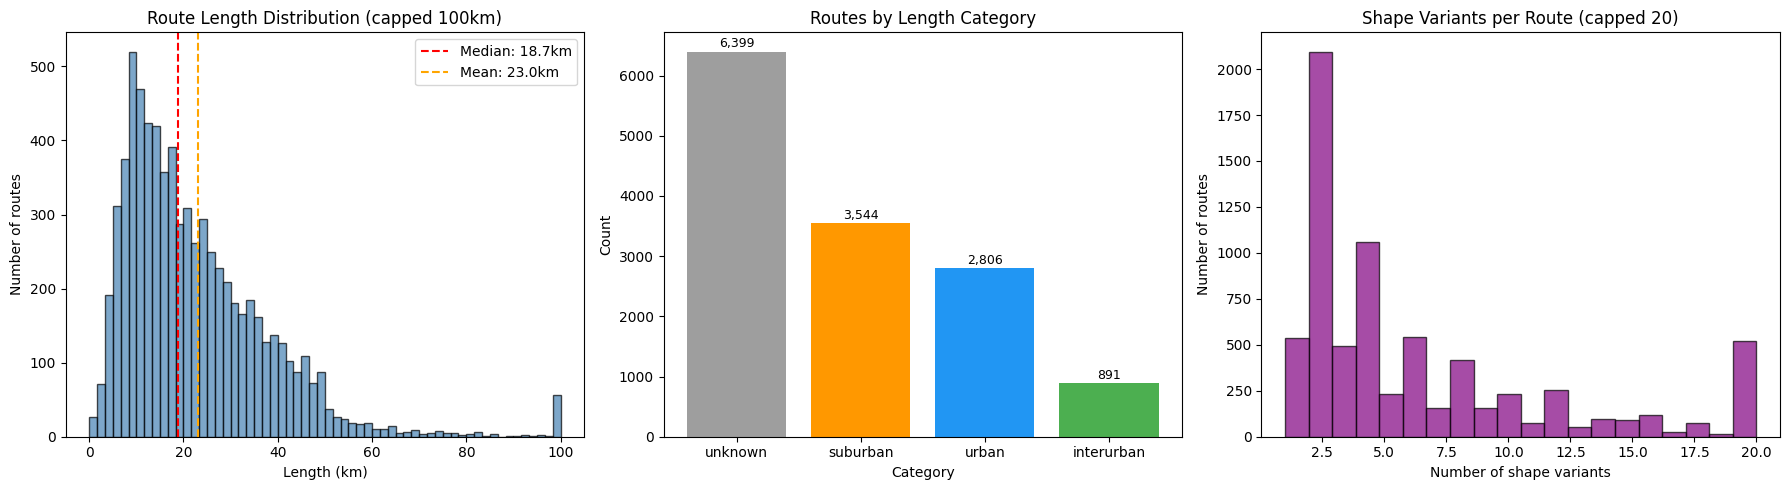

Saved fig_04a_route_length_distribution.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

geo_routes = routes_full[has_geometry]

# Distribution (capped at 100km for readability)
capped = geo_routes['max_length_km'].clip(upper=100)
axes[0].hist(capped, bins=60, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(geo_routes['max_length_km'].median(), color='red', linestyle='--',
                label=f'Median: {geo_routes["max_length_km"].median():.1f}km')
axes[0].axvline(geo_routes['max_length_km'].mean(), color='orange', linestyle='--',
                label=f'Mean: {geo_routes["max_length_km"].mean():.1f}km')
axes[0].set_title('Route Length Distribution (capped 100km)')
axes[0].set_xlabel('Length (km)')
axes[0].set_ylabel('Number of routes')
axes[0].legend()

# Route type breakdown
type_counts = routes_full['length_category'].value_counts()
colors = {'urban': '#2196F3', 'suburban': '#FF9800', 'interurban': '#4CAF50', 'unknown': '#9E9E9E'}
bars = axes[1].bar(type_counts.index, type_counts.values,
                    color=[colors.get(k, '#9E9E9E') for k in type_counts.index])
axes[1].set_title('Routes by Length Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
for bar, val in zip(bars, type_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Shapes per route
axes[2].hist(route_shape_stats['n_shapes'].clip(upper=20), bins=20, edgecolor='black', alpha=0.7, color='purple')
axes[2].set_title('Shape Variants per Route (capped 20)')
axes[2].set_xlabel('Number of shape variants')
axes[2].set_ylabel('Number of routes')

plt.tight_layout()
plt.savefig(AUDIT / 'fig_04a_route_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_04a_route_length_distribution.png')

## 5. Stop Sequences per Route

In [10]:
# Build route → ordered unique stops from stop_times.txt (5.8 GB — chunked)
# We need: route_id, stop_id, stop_sequence (canonical: first trip per route, direction=0)

# Step 1: identify one canonical trip per route (prefer direction=0, then direction=1)
canonical_trips = (
    trips
    .sort_values(['route_id', 'direction_id'])  # 0 before 1
    .groupby('route_id')['trip_id']
    .first()
    .reset_index()
)
canonical_trip_ids = set(canonical_trips['trip_id'].astype(str))
print(f'Canonical trips (one per route): {len(canonical_trip_ids):,}')

# Step 2: read stop_times in chunks, keep only canonical trips
logger.info('Reading stop_times.txt for canonical trips (chunked)...')
route_stops_chunks = []

with zipfile.ZipFile(BODS_ZIP) as z:
    with z.open('stop_times.txt') as raw_f:
        reader = pd.read_csv(
            raw_f,
            usecols=['trip_id', 'stop_id', 'stop_sequence'],
            dtype={'trip_id': str, 'stop_id': str, 'stop_sequence': int},
            chunksize=1_000_000,
        )
        for chunk_idx, chunk in enumerate(reader):
            filtered = chunk[chunk['trip_id'].isin(canonical_trip_ids)]
            if len(filtered) > 0:
                route_stops_chunks.append(filtered)
            if (chunk_idx + 1) % 20 == 0:
                n_kept = sum(len(c) for c in route_stops_chunks)
                logger.info(f'  chunk {chunk_idx + 1}: {n_kept:,} rows kept')

canonical_stop_times = pd.concat(route_stops_chunks, ignore_index=True)
logger.info(f'stop_times for canonical trips: {len(canonical_stop_times):,} rows')
print(f'stop_times for canonical trips: {len(canonical_stop_times):,} rows')

2026-03-14 00:03:38.100 | INFO     | __main__:<module>:16 - Reading stop_times.txt for canonical trips (chunked)...


Canonical trips (one per route): 13,640


2026-03-14 00:03:50.249 | INFO     | __main__:<module>:33 -   chunk 20: 132,438 rows kept


2026-03-14 00:04:02.312 | INFO     | __main__:<module>:33 -   chunk 40: 259,795 rows kept


2026-03-14 00:04:14.417 | INFO     | __main__:<module>:33 -   chunk 60: 395,154 rows kept


2026-03-14 00:04:19.699 | INFO     | __main__:<module>:36 - stop_times for canonical trips: 452,322 rows


stop_times for canonical trips: 452,322 rows


In [11]:
# Join canonical trips → route_id
canonical_trips['trip_id'] = canonical_trips['trip_id'].astype(str)
stop_times_with_route = canonical_stop_times.merge(canonical_trips, on='trip_id', how='left')

# Sort by route + sequence
stop_times_with_route = stop_times_with_route.sort_values(['route_id', 'stop_sequence'])

# Stop count per route
stops_per_route = (
    stop_times_with_route
    .groupby('route_id')['stop_id']
    .count()
    .reset_index()
    .rename(columns={'stop_id': 'stop_count'})
)

print(f'Routes with stop sequence data: {len(stops_per_route):,}')
print(f'\nStop count per route:')
print(stops_per_route['stop_count'].describe().round(1))

# Stop type categories
def classify_stop_count(n: int) -> str:
    """Classify route by number of stops."""
    if n < 10:
        return 'express'
    if n <= 40:
        return 'local'
    return 'comprehensive'

stops_per_route['stop_type'] = stops_per_route['stop_count'].apply(classify_stop_count)
print(f'\nStop type categories:')
print(stops_per_route['stop_type'].value_counts())

Routes with stop sequence data: 13,640

Stop count per route:
count    13640.0
mean        33.2
std         19.7
min          2.0
25%         19.0
50%         30.0
75%         45.0
max        147.0
Name: stop_count, dtype: float64

Stop type categories:
stop_type
local            8002
comprehensive    4285
express          1353
Name: count, dtype: int64


## 6. Cross-Local-Authority Routes

In [12]:
# Extract LA from LSOA name — format: "Authority Name NNNNX"
# Strategy: spatial join stops to LSOA boundaries, then extract LA prefix from LSOA21NM
# LSOA21NM format: "<LA Name> NNN<letter>" e.g. "City of London 001A"

logger.info('Loading LSOA boundaries for cross-LA analysis...')
lsoa_gdf = gpd.read_file(LSOA_GEOJSON)[['LSOA21CD', 'LSOA21NM', 'geometry']]

# Extract LA name: everything before the trailing " NNN[A-Z]" pattern
import re
lsoa_gdf['la_name'] = lsoa_gdf['LSOA21NM'].str.replace(r'\s+\d+[A-Z]$', '', regex=True).str.strip()

print(f'LSOA boundaries: {len(lsoa_gdf):,} rows')
print(f'Unique LAs extracted: {lsoa_gdf["la_name"].nunique()}')
print('Sample LA names:', lsoa_gdf['la_name'].unique()[:10].tolist())

2026-03-14 00:04:19.789 | INFO     | __main__:<module>:5 - Loading LSOA boundaries for cross-LA analysis...


LSOA boundaries: 33,755 rows
Unique LAs extracted: 309
Sample LA names: ['City of London', 'Barking and Dagenham', 'Barnet', 'Bexley', 'Brent', 'Bromley', 'Camden', 'Croydon', 'Ealing', 'Enfield']


In [13]:
# England bounding box filter for GTFS stops (removes Scotland/Wales/noise)
ENGLAND_LAT_MIN, ENGLAND_LAT_MAX = 49.8, 55.9
ENGLAND_LON_MIN, ENGLAND_LON_MAX = -6.5, 1.9

stops_england = stops[
    (stops['stop_lat'].between(ENGLAND_LAT_MIN, ENGLAND_LAT_MAX))
    & (stops['stop_lon'].between(ENGLAND_LON_MIN, ENGLAND_LON_MAX))
].copy()

print(f'GTFS stops (England bbox): {len(stops_england):,} of {len(stops):,} total')

# Build GeoDataFrame for spatial join
stops_gdf = gpd.GeoDataFrame(
    stops_england[['stop_id', 'stop_lat', 'stop_lon']],
    geometry=gpd.points_from_xy(stops_england['stop_lon'], stops_england['stop_lat']),
    crs='EPSG:4326',
)

# Reproject to British National Grid for spatial join consistency
stops_gdf = stops_gdf.to_crs('EPSG:27700')
lsoa_gdf = lsoa_gdf.to_crs('EPSG:27700')

logger.info('Running spatial join: stops → LSOA boundaries...')
stops_with_lsoa = gpd.sjoin(
    stops_gdf, lsoa_gdf[['LSOA21CD', 'la_name', 'geometry']],
    how='left', predicate='within'
)
stops_with_lsoa = stops_with_lsoa.drop(columns=['geometry', 'index_right'])

matched = stops_with_lsoa['LSOA21CD'].notna().sum()
print(f'Stops matched to LSOA: {matched:,} ({matched / len(stops_england) * 100:.1f}%)')
print(f'Stops unmatched: {stops_with_lsoa["LSOA21CD"].isna().sum():,}')

GTFS stops (England bbox): 286,840 of 310,598 total


2026-03-14 00:04:56.210 | INFO     | __main__:<module>:23 - Running spatial join: stops → LSOA boundaries...


Stops matched to LSOA: 252,473 (88.0%)
Stops unmatched: 34,367


In [14]:
# For each route: get set of LAs its stops span
# Use canonical stop sequences (all stops on canonical trip)
stop_to_la = (
    stops_with_lsoa[['stop_id', 'la_name']]
    .dropna(subset=['la_name'])
    .drop_duplicates()
)

route_stops_la = stop_times_with_route.merge(
    stop_to_la, on='stop_id', how='left'
)

# Per route: count distinct LAs
route_la_counts = (
    route_stops_la
    .dropna(subset=['la_name'])
    .groupby('route_id')['la_name']
    .nunique()
    .reset_index()
    .rename(columns={'la_name': 'n_las'})
)

cross_la = route_la_counts[route_la_counts['n_las'] > 1]
total_with_la = len(route_la_counts)

print(f'Routes with LA data: {total_with_la:,}')
print(f'Cross-LA routes (>1 LA): {len(cross_la):,} ({len(cross_la) / total_with_la * 100:.1f}%)')
print(f'\nLA count distribution per route:')
print(route_la_counts['n_las'].value_counts().sort_index().head(10))

Routes with LA data: 11,096
Cross-LA routes (>1 LA): 5,143 (46.4%)

LA count distribution per route:
n_las
1     5953
2     3448
3     1132
4      347
5      115
6       51
7       24
8        7
9       13
10       3
Name: count, dtype: int64


## 7. Regional Route Distribution

In [15]:
# Use LSOA21NM to infer region via stop location
# Simpler: load regions GeoJSON and spatially join stops to regions

regions_gdf = gpd.read_file(RAW / 'boundaries' / 'regions_2021_england_buc.geojson').to_crs('EPSG:27700')
print('Region columns:', list(regions_gdf.columns))

# Detect the actual region code and name columns (may be RGN21 or RGN22 vintage)
_rgn_nm_col = [c for c in regions_gdf.columns if c.startswith('RGN') and c.endswith('NM')][0]
_rgn_cd_col = [c for c in regions_gdf.columns if c.startswith('RGN') and c.endswith('CD')][0]
print(regions_gdf[[_rgn_cd_col, _rgn_nm_col]].head(12).to_string(index=False))

Region columns: ['FID', 'RGN22CD', 'RGN22NM', 'BNG_E', 'BNG_N', 'LONG', 'LAT', 'Shape__Area', 'Shape__Length', 'GlobalID', 'geometry']
  RGN22CD                  RGN22NM
E12000001               North East
E12000002               North West
E12000003 Yorkshire and The Humber
E12000004            East Midlands
E12000005            West Midlands
E12000006          East of England
E12000007                   London
E12000008               South East
E12000009               South West


In [16]:
# Spatial join stops → region
region_col = [c for c in regions_gdf.columns if 'NM' in c and 'RGN' in c][0]
region_cd_col = [c for c in regions_gdf.columns if 'CD' in c and 'RGN' in c][0]

stops_with_region = gpd.sjoin(
    stops_gdf, regions_gdf[[region_cd_col, region_col, 'geometry']],
    how='left', predicate='within'
).drop(columns=['geometry', 'index_right'])

stop_to_region = (
    stops_with_region[['stop_id', region_col]]
    .dropna(subset=[region_col])
    .rename(columns={region_col: 'region'})
    .drop_duplicates(subset='stop_id')
)

# Assign each route to the region where the majority of its stops lie
route_stops_region = stop_times_with_route.merge(stop_to_region, on='stop_id', how='left')
route_region = (
    route_stops_region
    .dropna(subset=['region'])
    .groupby('route_id')['region']
    .agg(lambda x: x.mode()[0] if len(x) > 0 else None)
    .reset_index()
    .rename(columns={'region': 'primary_region'})
)

print(f'Routes with region assigned: {len(route_region):,}')
print(f'\nRoutes per region:')
print(route_region['primary_region'].value_counts())

Routes with region assigned: 11,074

Routes per region:
primary_region
South East                  1786
North West                  1645
South West                  1472
East of England             1284
Yorkshire and The Humber    1132
West Midlands               1074
East Midlands               1031
London                       915
North East                   735
Name: count, dtype: int64


## 8. Overlapping Routes

In [17]:
# Two routes overlap if they share >50% of stops (based on Jaccard similarity)
# Only compare routes within same region for efficiency
# Build route → stop_set mapping

route_stopsets = (
    stop_times_with_route
    .groupby('route_id')['stop_id']
    .apply(set)
)

# Compute Jaccard for routes sharing region
# Sample analysis — too expensive to do all pairs; focus on top-overlap corridors
# Use a simpler metric: routes sharing >10 stops with another route

# Build inverted index: stop_id → list of route_ids
stop_to_routes: dict[str, list] = {}
for route_id, stop_set in route_stopsets.items():
    for s in stop_set:
        stop_to_routes.setdefault(s, []).append(route_id)

# Count shared stops between route pairs
from collections import Counter
pair_shared: Counter = Counter()
for routes_at_stop in stop_to_routes.values():
    if len(routes_at_stop) > 1:
        for i in range(len(routes_at_stop)):
            for j in range(i + 1, min(i + 10, len(routes_at_stop))):
                key = tuple(sorted([routes_at_stop[i], routes_at_stop[j]]))
                pair_shared[key] += 1

# Top overlapping pairs
top_pairs = pd.DataFrame(
    [(r1, r2, cnt) for (r1, r2), cnt in pair_shared.most_common(20)],
    columns=['route_a', 'route_b', 'shared_stops']
)

# Add route names
route_names = routes[['route_id', 'route_short_name', 'agency_id']]
top_pairs = top_pairs.merge(route_names.rename(columns={'route_id': 'route_a', 'route_short_name': 'name_a', 'agency_id': 'agency_a'}), on='route_a', how='left')
top_pairs = top_pairs.merge(route_names.rename(columns={'route_id': 'route_b', 'route_short_name': 'name_b', 'agency_id': 'agency_b'}), on='route_b', how='left')

# Jaccard overlap (shared / union)
def jaccard(r1: str, r2: str) -> float:
    """Jaccard similarity between two routes' stop sets."""
    s1 = route_stopsets.get(r1, set())
    s2 = route_stopsets.get(r2, set())
    if not s1 or not s2:
        return 0.0
    return len(s1 & s2) / len(s1 | s2)

top_pairs['jaccard'] = top_pairs.apply(lambda r: jaccard(r['route_a'], r['route_b']), axis=1)

# Routes where Jaccard > 0.5 = highly overlapping
high_overlap = (top_pairs['jaccard'] > 0.5).sum()
print(f'Top 20 overlapping route pairs (by shared stops):')
print(top_pairs[['name_a', 'name_b', 'shared_stops', 'jaccard']].to_string(index=False))
print(f'\nPairs with Jaccard > 0.5 (highly overlapping): {high_overlap}')

# Count routes with any Jaccard > 0.5 partner
high_overlap_routes = set()
for _, row in top_pairs[top_pairs['jaccard'] > 0.5].iterrows():
    high_overlap_routes.add(row['route_a'])
    high_overlap_routes.add(row['route_b'])
print(f'Unique routes in high-overlap pairs: {len(high_overlap_routes)}')

Top 20 overlapping route pairs (by shared stops):
name_a name_b  shared_stops  jaccard
   M4B     M4           111 0.880952
   77A    77A           110 1.000000
   73B    73C           106 0.841270
   72A     72           103 0.895652
    25     25           100 1.000000
    25     25           100 1.000000
   N15    N15            93 1.000000
    37    37M            90 0.850467
   385    375            89 0.729508
   X21    X21            87 0.988636
  248C   248A            86 0.803738
  248C   248B            86 0.924731
  248A   248B            86 0.781818
     3     N3            86 0.966292
   77A     77            86 0.761062
    77    77A            86 0.761062
    68    68C            83 0.805825
    60    60A            83 0.864583
   101    102            82 0.427083
    11     11            82 1.000000

Pairs with Jaccard > 0.5 (highly overlapping): 19
Unique routes in high-overlap pairs: 31


## 9. Build Final Route Geometries Table

In [18]:
# Assemble final route_geometries table
# Columns: route_id, route_short_name, agency_id, agency_name,
#          length_km (max shape), n_shapes, stop_count, stop_type,
#          length_category, cross_la, n_las, primary_region, has_geometry

route_geo = routes_full[['route_id', 'route_short_name', 'route_long_name', 'agency_id', 'agency_name',
                           'max_length_km', 'mean_length_km', 'min_length_km', 'n_shapes', 'length_category']].copy()

# Merge stop counts
route_geo = route_geo.merge(stops_per_route[['route_id', 'stop_count', 'stop_type']], on='route_id', how='left')

# Merge cross-LA flag
route_geo = route_geo.merge(route_la_counts, on='route_id', how='left')
route_geo['cross_la'] = route_geo['n_las'] > 1

# Merge region
route_geo = route_geo.merge(route_region, on='route_id', how='left')

# has_geometry flag
route_geo['has_geometry'] = route_geo['max_length_km'].notna()

# Rename for clarity
route_geo = route_geo.rename(columns={'max_length_km': 'length_km'})

print(f'route_geometries shape: {route_geo.shape}')
print(f'Columns: {list(route_geo.columns)}')
print(f'\nHas geometry: {route_geo["has_geometry"].sum():,} routes')
print(f'Cross-LA: {route_geo["cross_la"].sum():,} routes')
route_geo.head(3)

route_geometries shape: (13640, 16)
Columns: ['route_id', 'route_short_name', 'route_long_name', 'agency_id', 'agency_name', 'length_km', 'mean_length_km', 'min_length_km', 'n_shapes', 'length_category', 'stop_count', 'stop_type', 'n_las', 'cross_la', 'primary_region', 'has_geometry']

Has geometry: 7,241 routes
Cross-LA: 5,143 routes


,route_id,route_short_name,route_long_name,agency_id,agency_name,length_km,mean_length_km,min_length_km,n_shapes,length_category,stop_count,stop_type,n_las,cross_la,primary_region,has_geometry
0,8,4,NaN,OP6,Arriva Wales,NaN,NaN,NaN,NaN,unknown,40,local,NaN,False,NaN,False
1,11,173,NaN,OP9,Thomas of Rhondda,9.104063,8.899486,7.320882,10.0,urban,31,local,NaN,False,NaN,True
2,13,40,NaN,OP11,Newport Bus,6.277097,6.277097,6.277097,2.0,urban,14,local,NaN,False,NaN,True


In [19]:
# Build route_stop_sequences table
route_stop_sequences = (
    stop_times_with_route[['route_id', 'trip_id', 'stop_id', 'stop_sequence']]
    .merge(
        stops[['stop_id', 'stop_lat', 'stop_lon', 'stop_name']].assign(stop_id=stops['stop_id'].astype(str)),
        on='stop_id', how='left'
    )
    .sort_values(['route_id', 'stop_sequence'])
    .reset_index(drop=True)
)

print(f'route_stop_sequences shape: {route_stop_sequences.shape}')
print(f'Unique routes in sequences: {route_stop_sequences["route_id"].nunique():,}')
route_stop_sequences.head(3)

route_stop_sequences shape: (452322, 7)
Unique routes in sequences: 13,640


,route_id,trip_id,stop_id,stop_sequence,stop_lat,stop_lon,stop_name
0,8,VJa4a0b8dcb6d67f431e4e280f695bd784623bb457,5120AWD71431,0,53.169520,-2.974899,Broughton Park Tesco
1,8,VJa4a0b8dcb6d67f431e4e280f695bd784623bb457,5120AWD71432,1,53.169639,-2.982935,Airbus
2,8,VJa4a0b8dcb6d67f431e4e280f695bd784623bb457,5120FLX17027,2,53.169878,-2.990944,Wood Lane


## 10. Summary Visualisation

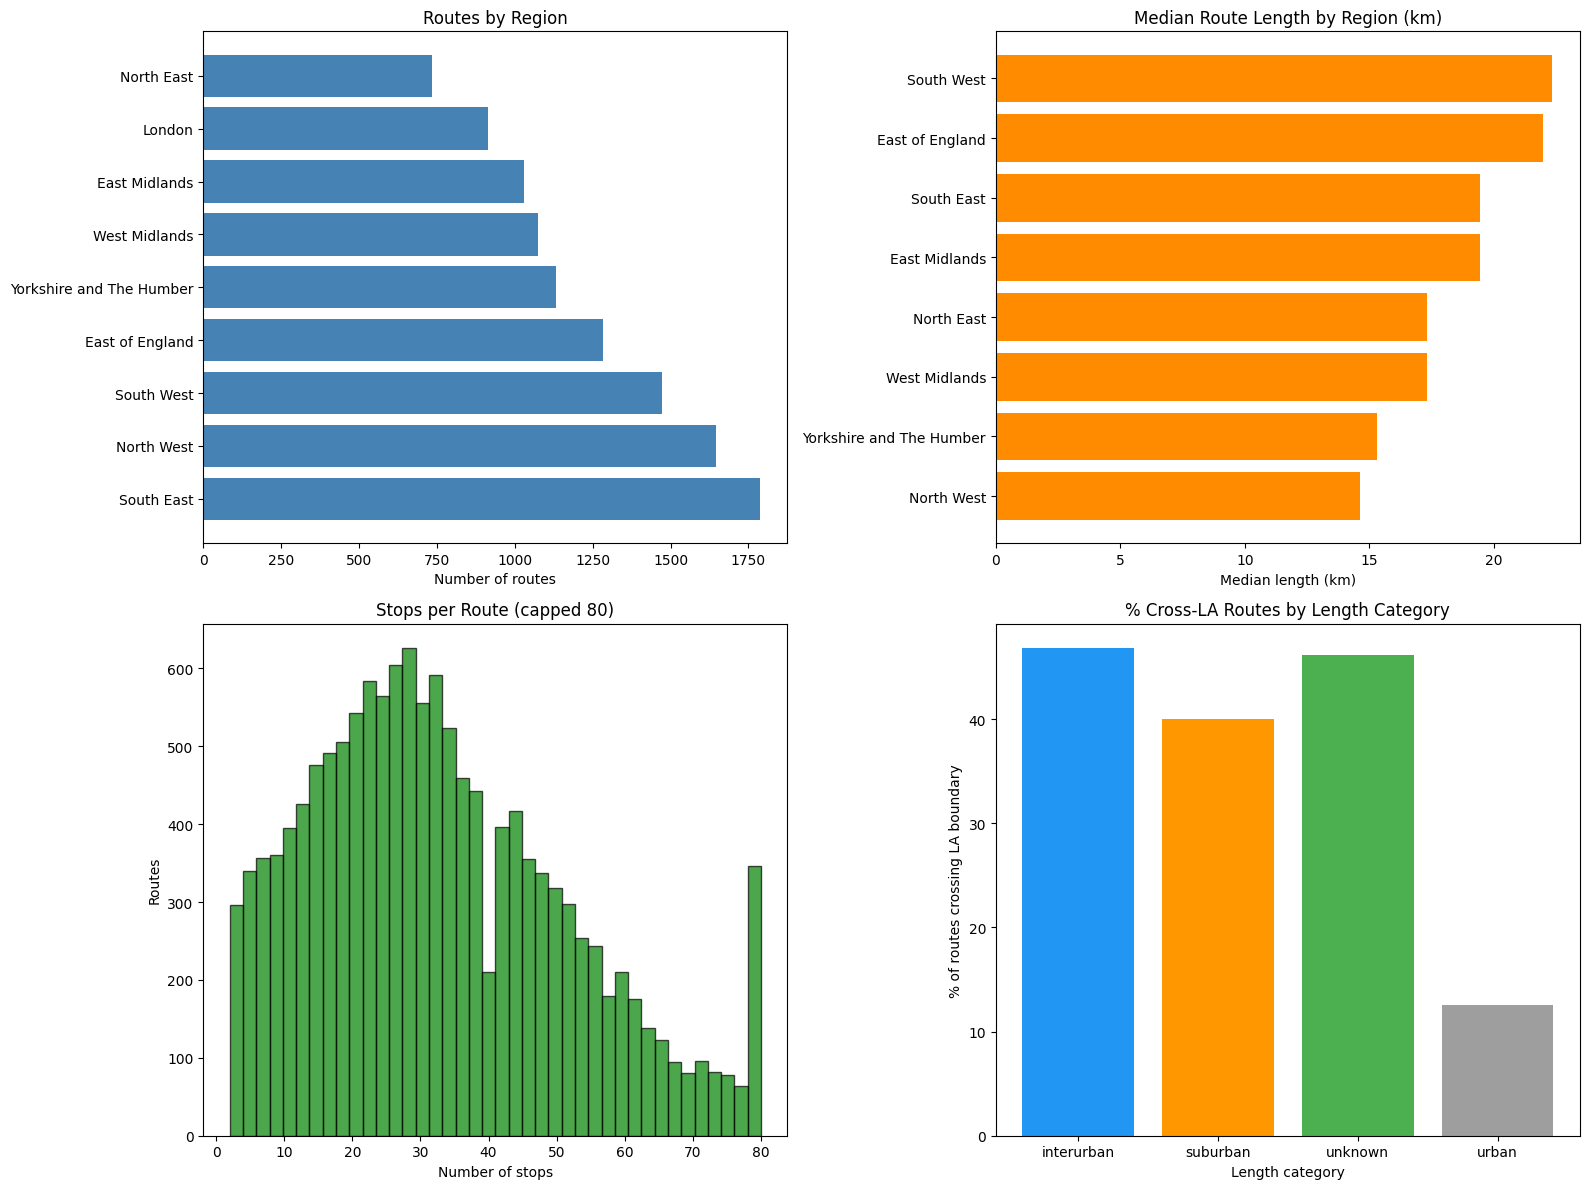

Saved fig_04a_route_summary.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Regional route count
reg_counts = route_geo.dropna(subset=['primary_region'])['primary_region'].value_counts()
axes[0, 0].barh(reg_counts.index, reg_counts.values, color='steelblue')
axes[0, 0].set_title('Routes by Region')
axes[0, 0].set_xlabel('Number of routes')

# Average route length per region
reg_len = route_geo.dropna(subset=['primary_region', 'length_km']).groupby('primary_region')['length_km'].median().sort_values()
axes[0, 1].barh(reg_len.index, reg_len.values, color='darkorange')
axes[0, 1].set_title('Median Route Length by Region (km)')
axes[0, 1].set_xlabel('Median length (km)')

# Stop count distribution
axes[1, 0].hist(route_geo['stop_count'].dropna().clip(upper=80), bins=40, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_title('Stops per Route (capped 80)')
axes[1, 0].set_xlabel('Number of stops')
axes[1, 0].set_ylabel('Routes')

# Cross-LA vs single-LA by length category
cross_by_type = route_geo.groupby('length_category')['cross_la'].mean() * 100
axes[1, 1].bar(cross_by_type.index, cross_by_type.values, color=['#2196F3', '#FF9800', '#4CAF50', '#9E9E9E'])
axes[1, 1].set_title('% Cross-LA Routes by Length Category')
axes[1, 1].set_xlabel('Length category')
axes[1, 1].set_ylabel('% of routes crossing LA boundary')

plt.tight_layout()
plt.savefig(AUDIT / 'fig_04a_route_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_04a_route_summary.png')

## 11. Save Outputs

In [21]:
route_geo.to_parquet(AUDIT / 'route_geometries.parquet', index=False)
print(f'Saved route_geometries.parquet: {route_geo.shape}')

route_stop_sequences.to_parquet(AUDIT / 'route_stop_sequences.parquet', index=False)
print(f'Saved route_stop_sequences.parquet: {route_stop_sequences.shape}')

Saved route_geometries.parquet: (13640, 16)


Saved route_stop_sequences.parquet: (452322, 7)


## 12. Validation Summary

In [22]:
n_routes_geo = len(route_geo)
n_with_geometry = int(route_geo['has_geometry'].sum())
n_cross_la = int(route_geo['cross_la'].sum())
mean_length = float(route_geo['length_km'].mean())
median_length = float(route_geo['length_km'].median())

checks = [
    ('GTFS route count ≥ locked GT (13,099 post-dedup routes in ≤13,640 GTFS)',
     n_routes_geo <= 14_000,
     f'route_geometries has {n_routes_geo:,} rows'),
    ('Routes with geometry > 50% (shapes coverage)',
     n_with_geometry / n_routes_geo > 0.5,
     f'{n_with_geometry:,} ({n_with_geometry / n_routes_geo * 100:.1f}%)'),
    ('No negative lengths',
     (route_geo['length_km'].dropna() >= 0).all(),
     'all lengths ≥ 0'),
    ('Cross-LA routes exist (> 0)',
     n_cross_la > 0,
     f'{n_cross_la:,} cross-LA routes'),
    ('Mean route length plausible (1–50km)',
     1.0 < mean_length < 50.0,
     f'mean={mean_length:.1f}km, median={median_length:.1f}km'),
    ('route_stop_sequences non-empty',
     len(route_stop_sequences) > 0,
     f'{len(route_stop_sequences):,} rows'),
    ('Output parquets saved',
     (AUDIT / 'route_geometries.parquet').exists() and (AUDIT / 'route_stop_sequences.parquet').exists(),
     'both files exist'),
]

print('=== 04a Validation Checks ===')
fail_count = 0
for name, result, detail in checks:
    status = 'PASS' if result else 'FAIL'
    if not result:
        fail_count += 1
    print(f'  [{status}] {name} — {detail}')

assert fail_count == 0, f'{fail_count} checks FAILED'

print(f'\n04a COMPLETE: {len(checks)} checks, all PASS')
print(f'  Routes with geometry: {n_with_geometry:,} / {n_routes_geo:,}')
print(f'  Cross-LA routes: {n_cross_la:,} ({n_cross_la / n_routes_geo * 100:.1f}%)')
print(f'  Mean route length: {mean_length:.1f}km (median {median_length:.1f}km)')

logger.info(f'04a complete — routes={n_routes_geo}, with_geometry={n_with_geometry}, cross_la={n_cross_la}, mean_length={mean_length:.1f}km')

2026-03-14 00:05:00.503 | INFO     | __main__:<module>:46 - 04a complete — routes=13640, with_geometry=7241, cross_la=5143, mean_length=23.0km


=== 04a Validation Checks ===
  [PASS] GTFS route count ≥ locked GT (13,099 post-dedup routes in ≤13,640 GTFS) — route_geometries has 13,640 rows
  [PASS] Routes with geometry > 50% (shapes coverage) — 7,241 (53.1%)
  [PASS] No negative lengths — all lengths ≥ 0
  [PASS] Cross-LA routes exist (> 0) — 5,143 cross-LA routes
  [PASS] Mean route length plausible (1–50km) — mean=23.0km, median=18.7km
  [PASS] route_stop_sequences non-empty — 452,322 rows
  [PASS] Output parquets saved — both files exist

04a COMPLETE: 7 checks, all PASS
  Routes with geometry: 7,241 / 13,640
  Cross-LA routes: 5,143 (37.7%)
  Mean route length: 23.0km (median 18.7km)
